<a href="https://colab.research.google.com/github/fiapostechfase1/tech-challenge/blob/Erick/Tech_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge

## 1. Descrição do Problema

<p>Imagine agora, que você vai atuar como Expert em Data Analytics em uma
empresa que exporta vinhos do Brasil para o mundo todo.
Sua área é recém-criada dentro da empresa, e você será responsável
pelos relatórios iniciais a serem apresentados em uma reunião de investidores e
acionistas, explicando a quantidade de vinhos exportados e os fatores externos
que podem vir a surgir e que interferem nas análises:</p>
<ul>
    <li>1. Dados climáticos. </li>
    <li>2. Dados demográficos.</li>
    <li>3. Dados econômicos.</li>
    <li>4. Dados de avaliações de vinhos.</li>
</ul>

<p>O Head de Dados pediu para que você construísse uma tabela contendo
as seguintes informações:</p>
<ul>
    <li>a. País de origem (Brasil). </li>
    <li>b. País de destino. </li>
    <li>c. Quantidade em litros de vinho exportado (utilize: 1KG =1L). </li>
    <li>d. Valor em US$. </li>
</ul>

<p>Os dados que lhe forneceram são de uma vinícola parceira, e podem ser
encontrados aqui: http://vitibrasil.cnpuv.embrapa.br/index.php?opcao=opt_01
</br>Seu objetivo é dizer o montante de venda de exportação nos últimos 15
anos, separando a análise por país e trazendo quais as prospecções futuras e
possíveis ações para uma melhoria nas exportações. Construa gráficos atraentes e que passem a ideia central para que os acionistas e investidores
possam seguir em frente com suas ações.</p>

## 2. Carregando Dados

### 2.1 Importando Bibliotecas Necessárias

Inicio o projeto importando as bibliotecas que serão utilizadas para o tratamento e a visualização de dados.

In [1]:
# importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 2.2 Carregando dados

Trazendo a base de dados de exportação de vinhos para o projeto.

In [2]:
# importando datasets
dados = pd.read_csv('https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Erick/dados/ExpVinho.csv', sep = '\t')

cotacao = pd.read_csv('https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Erick/dados/USD_BRL%20Dados%20Hist%C3%B3ricos.csv', sep = ',')

producao = pd.read_csv('https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Erick/dados/Producao.csv', sep = ';', skipfooter = 47)

clima = pd.read_csv('https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Erick/dados/dados_A840_M_2010-01-01_2024-12-31.csv', sep = ';', skiprows = 10)

<ipython-input-2-6c523b6b322d>:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  producao = pd.read_csv('https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Erick/dados/Producao.csv', sep = ';', skipfooter = 47)


In [3]:
# primeira visualização do dataset
dados.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# visualização da cotação mensal do dólar
cotacao.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,01.12.2024,"6,1778","6,0002","6,3144","5,8665",NaN,"3,43%"
1,01.11.2024,"5,9730","5,7885","6,1159","5,6335",NaN,"3,22%"
2,01.10.2024,"5,7867","5,4501","5,7949","5,4037",NaN,"6,21%"
3,01.09.2024,"5,4482","5,6464","5,6769","5,3938",NaN,"-2,89%"
4,01.08.2024,"5,6103","5,6507","5,8648","5,3755",NaN,"-0,70%"


In [5]:
# visualização dos dados de produção de vinhos de todo o período
producao.head()

,id,control,produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,VINHO DE MESA,VINHO DE MESA,217208604,154264651,146953297,116710345,193875345,177401209,144565438,...,196173123,210308560,86319015,255015187,218375636,144629737,124200414,173899995,195031611,169762429
1,2,vm_Tinto,Tinto,174224052,121133369,118180926,88589019,146544484,144274134,118360170,...,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
2,3,vm_Branco,Branco,748400,1160500,1812367,243900,4138768,1441507,1871473,...,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
3,4,vm_Rosado,Rosado,42236152,31970782,26960004,27877426,43192093,31685568,24333795,...,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246


In [6]:
# visualização da média climática mensal entre 2010 à 2024
clima.head()

,Data Medicao,"NUMERO DE DIAS COM PRECIP. PLUV, MENSAL (AUT)(número)","PRECIPITACAO TOTAL, MENSAL (AUT)(mm)","PRESSAO ATMOSFERICA, MEDIA MENSAL (AUT)(mB)","TEMPERATURA MEDIA, MENSAL (AUT)(°C)","VENTO, VELOCIDADE MAXIMA MENSAL (AUT)(m/s)","VENTO, VELOCIDADE MEDIA MENSAL (AUT)(m/s)"
0,31/01/2010,18.0,"278,4","941,5","21,9",7,"2,5"
1,28/02/2010,14.0,"161,4","942,1",23,"9,7","2,8"
2,31/03/2010,19.0,"58,4","942,6","20,7",7,"2,2"
3,30/04/2010,14.0,"136,4","946,2","17,6","8,5","2,4"
4,31/05/2010,21.0,"158,6",946,"14,3","6,8","2,2"


## 3. Preparando Dados Para Análise

Nessa etapa é feita a transformação dos dados necessárias, para que os dados estejam padronizados e prontos para que sejam criadas as primeiras visualizações.

### 3.1 Visão Geral dos Dados

Entendendo melhor os dados disponíveis, e transformando-os para que possam suprir as necessidades de visualização para responder as perguntas norteadoras.

#### 3.1.1 Tratando os Dados de **Exportação**

In [7]:
# entendendo as dimensões do DataFrame
dados.shape

(141, 112)

In [8]:
# separando colunas em lista, excluindo Id e País
colunas = dados.columns.tolist()
colunas_anos = [col for col in colunas if col not in ['Id', 'País']]

In [9]:
# selecionando a primeira aparição de ano como Quantidade(Kg) e a segunda como Valor(US$)
colunas_quantidade = colunas_anos[::2]
colunas_valor = colunas_anos[1::2]

In [10]:
# separando as colunas da base de dados: Quantidade
dados_quantidade = dados[['País'] + colunas_quantidade].melt(id_vars='País', var_name='Ano', value_name='Quantidade')
dados_quantidade.head()

,País,Ano,Quantidade
0,Afeganistão,1970,0
1,África do Sul,1970,0
2,"Alemanha, República Democrática",1970,0
3,Angola,1970,0
4,Anguilla,1970,0


In [11]:
# separando as colunas da base de dados: Valor
dados_valor = dados[['País'] + colunas_valor].copy()
dados_valor.columns = ['País'] + colunas_quantidade
dados_valor = dados_valor.melt(id_vars='País', var_name='Ano', value_name='Valor')
dados_valor.head()

,País,Ano,Valor
0,Afeganistão,1970,0
1,África do Sul,1970,0
2,"Alemanha, República Democrática",1970,0
3,Angola,1970,0
4,Anguilla,1970,0


In [12]:
# unificando as tabelas de Quantidade e Valor em uma única tabela
dados_final = pd.merge(dados_quantidade, dados_valor, on=['País', 'Ano'])

In [13]:
# exibindo a tabela final
dados_final.head()

,País,Ano,Quantidade,Valor
0,Afeganistão,1970,0,0
1,África do Sul,1970,0,0
2,"Alemanha, República Democrática",1970,0,0
3,Angola,1970,0,0
4,Anguilla,1970,0,0


In [14]:
# selecionando apenas os resultados dos últimos 15 anos com relação ao DataFrame, ou seja, entre 2010 e 2024
dados_final['Ano'] = pd.to_numeric(dados_final['Ano'], errors='coerce')
ano_max = dados_final['Ano'].max()
anos_recente = dados_final[dados_final['Ano'] >= ano_max - 14]
anos_recente.head()

,País,Ano,Quantidade,Valor
5640,Afeganistão,2010,0,0
5641,África do Sul,2010,0,0
5642,"Alemanha, República Democrática",2010,27715,138666
5643,Angola,2010,33557,189891
5644,Anguilla,2010,0,0


In [15]:
# reestruturando os nomes dos países
anos_recente.reset_index(drop = True, inplace = True)
anos_recente['País'] = anos_recente['País'].str.replace(r',.*', '', regex=True)
anos_recente.head()

<ipython-input-15-20c8d7186004>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anos_recente['País'] = anos_recente['País'].str.replace(r',.*', '', regex=True)


,País,Ano,Quantidade,Valor
0,Afeganistão,2010,0,0
1,África do Sul,2010,0,0
2,Alemanha,2010,27715,138666
3,Angola,2010,33557,189891
4,Anguilla,2010,0,0


In [16]:
# entendendo a estruturação do novo formato do DataFrame
anos_recente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2115 entries, 0 to 2114
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   País        2115 non-null   object
 1   Ano         2115 non-null   int64 
 2   Quantidade  2115 non-null   int64 
 3   Valor       2115 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 66.2+ KB


In [17]:
# verificando a existência de dados duplicados
anos_recente.duplicated().sum()

np.int64(0)

In [18]:
# analisando as estatísticas básicas
pd.set_option('display.float_format', '{:.2f}'.format)
anos_recente[['Valor', 'Quantidade']].describe()

,Valor,Quantidade
count,2115.00,2115.00
mean,54023.44,29780.27
std,483430.54,301504.14
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,3172.50,787.00
max,14795694.00,6522527.00


#### 3.1.2 Tratando os Dados de Cotação do Dólar

In [19]:
# selecionando as últimas cotações do dólar de cada mês durante 15 anos
cotacao['Data'] = pd.to_datetime(cotacao['Data'], format = '%d.%m.%Y')
cotacao['Data'] = cotacao['Data'].dt.strftime('%Y')
ultima_cotacao = cotacao[['Data','Último']]
ultima_cotacao.head()

,Data,Último
0,2024,"6,1778"
1,2024,"5,9730"
2,2024,"5,7867"
3,2024,"5,4482"
4,2024,"5,6103"


In [20]:
# verificando a estrutura da tabela de cotação do dólar
ultima_cotacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    180 non-null    object
 1   Último  180 non-null    object
dtypes: object(2)
memory usage: 2.9+ KB


In [21]:
# alterando os tipos das variáveis
ultima_cotacao.loc[:, 'Data'] = ultima_cotacao['Data'].astype(int)
ultima_cotacao.loc[:, 'Último'] = ultima_cotacao['Último'].str.replace(',', '.')
ultima_cotacao.loc[:, 'Último'] = ultima_cotacao['Último'].astype(float)
ultima_cotacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    180 non-null    object
 1   Último  180 non-null    object
dtypes: object(2)
memory usage: 2.9+ KB


In [22]:
# criando média anual da cotação do dólar
ultima_cotacao_ano = ultima_cotacao.groupby('Data')['Último'].mean()
ultima_cotacao_ano

,Último
Data,
2010,1.76
2011,1.67
2012,1.96
2013,2.18
2014,2.36
2015,3.39
2016,3.45
2017,3.20
2018,3.68


#### 3.1.3 Tratando os Dados de Produção de Vinho

In [23]:
# removendo as colunas colunas 'id' e 'control' e transformando 'produto' como índice
producao.drop(columns = ['id', 'control'], axis='x', inplace = True)
producao.set_index('produto', inplace=True)
producao.head()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
produto,,,,,,,,,,,,,,,,,,,,,
VINHO DE MESA,217208604,154264651,146953297,116710345,193875345,177401209,144565438,195359778,200053669,211252982,...,196173123,210308560,86319015,255015187,218375636,144629737,124200414,173899995,195031611,169762429
Tinto,174224052,121133369,118180926,88589019,146544484,144274134,118360170,154801826,162917363,154736439,...,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
Branco,748400,1160500,1812367,243900,4138768,1441507,1871473,4954387,5079748,7146395,...,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
Rosado,42236152,31970782,26960004,27877426,43192093,31685568,24333795,35603565,32056558,49370148,...,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246


In [24]:
# selecionando os últimos 14 anos do dataset, pois o dataset não possui dados de 2024
producao_recente = producao.iloc[:, -14:]
producao_recente.head()

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
produto,,,,,,,,,,,,,,
VINHO DE MESA,195267980,257840749,212777037,196904222,196173123,210308560,86319015,255015187,218375636,144629737,124200414,173899995,195031611,169762429
Tinto,157290088,210113358,175875432,163111797,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
Branco,35408083,46007504,34938249,32066403,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
Rosado,2569809,1719887,1963356,1726022,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246


In [25]:
# simulando os dados de 2024 com dados históricos
vinho_mesa = producao_recente.loc['VINHO DE MESA'].iloc[-2:].mean().astype(int)
tinto = producao_recente.loc['Tinto'].iloc[-2:].mean().astype(int)
branco = producao_recente.loc['Branco'].iloc[-2:].mean().astype(int)
rosado = producao_recente.loc['Rosado'].iloc[-2:].mean().astype(int)

producao_recente['2024'] = [vinho_mesa, tinto, branco, rosado]
producao_recente.head()

<ipython-input-25-17c7f51790e7>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  producao_recente['2024'] = [vinho_mesa, tinto, branco, rosado]


,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
produto,,,,,,,,,,,,,,,
VINHO DE MESA,195267980,257840749,212777037,196904222,196173123,210308560,86319015,255015187,218375636,144629737,124200414,173899995,195031611,169762429,182397020
Tinto,157290088,210113358,175875432,163111797,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884,151082549
Branco,35408083,46007504,34938249,32066403,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299,29054364
Rosado,2569809,1719887,1963356,1726022,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246,2260107


#### 3.1.4 Tratando os Dados Climáticos de Bento Gonçalves/RS

In [26]:
# reestruturando a tabela de dados climáticos
clima['Data Medicao'] = pd.to_datetime(clima['Data Medicao'], format = '%d/%m/%Y')
clima['ano'] = clima['Data Medicao'].dt.year
clima.rename(columns = {'NUMERO DE DIAS COM PRECIP. PLUV, MENSAL (AUT)(número)':'precipitacao_media_dias',
                        'PRECIPITACAO TOTAL, MENSAL (AUT)(mm)':'precipitacao_media', 'PRESSAO ATMOSFERICA, MEDIA MENSAL (AUT)(mB)':'pressao_media',
                        'TEMPERATURA MEDIA, MENSAL (AUT)(°C)':'temperatura_media','VENTO, VELOCIDADE MAXIMA MENSAL (AUT)(m/s)':'vento_max_media',
                        'VENTO, VELOCIDADE MEDIA MENSAL (AUT)(m/s)':'vento_media'}, inplace = True)

colunas_numericas = ['precipitacao_media_dias', 'precipitacao_media', 'pressao_media',
                     'temperatura_media', 'vento_max_media', 'vento_media']

for col in colunas_numericas:
    clima[col] = clima[col].astype(str).str.replace(',', '.').str.strip()
    clima[col] = pd.to_numeric(clima[col], errors='coerce')

media_anual = clima.groupby('ano')[colunas_numericas].mean()

media_anual

,precipitacao_media_dias,precipitacao_media,pressao_media,temperatura_media,vento_max_media,vento_media
ano,,,,,,
2010,14.08,135.98,944.22,17.31,8.74,2.68
2011,14.25,146.91,943.98,17.12,7.86,2.73
2012,9.50,111.92,944.34,18.28,8.16,2.82
2013,13.50,154.47,944.52,17.06,7.99,2.73
2014,14.58,168.65,944.76,18.18,8.80,2.92
2015,13.20,136.35,944.12,18.81,8.33,2.71
2016,11.17,150.76,944.47,17.18,7.66,2.77
2017,12.33,159.50,944.38,18.27,7.97,2.96
2018,13.00,150.20,944.31,17.57,7.62,2.76


Por fim, as bases de dados estão completamente formatadas e prontas para serem utilizadas nas visualizações de dados.

## 4. Visualização dos Dados

In [27]:
# função para plotar o valor desejado agrupado por ano
def plota_por_ano(x, ylabel, title, ylim):
    fig, ax = plt.subplots(figsize = (12, 6))
    dados_agrupados = anos_recente.groupby('Ano')[x].sum() / 1_000_000
    barras = ax.bar(dados_agrupados.index, dados_agrupados.values, color = 'blue')

    # adicionando o valor acima de cada barra
    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, altura,
                f'{altura:.2f}', ha='center', va='bottom')

    ax.bar(dados_agrupados.index, dados_agrupados.values)
    ax.grid(axis = 'y')
    plt.ylim(0, ylim)
    ax.set_xlabel('Ano')
    ax.set_xticks(dados_agrupados.index)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.show()

<p>Nos gráficos abaixo, é possível analisar que nos últimos 15 anos durante o período de 2010 e 2011, a empresa se manteve num patamar moderado. Porém, no ano de 2012, houve um aumento disparado na quantidade de vinho exportada, e em 2013 teve um aumento astronômico na receita de exportação de vinhos. Isso pode ser relacionado à diversos fatores, como:</p>
<ul>
    <li><a href='https://periodicos.unicesumar.edu.br/index.php/revcesumar/article/viewFile/4395/2718?utm_source=chatgpt.com'>Uma melhora na qualidade das uvas;</a></li>
    <li><a href='https://www.idealsoftwares.com.br/indices/dolar2013.html?utm_source=chatgpt.com'>Desvalorização do real frente ao dólar;</a></li>
    <li><a href='https://www25.senado.leg.br/web/atividade/pronunciamentos/-/p/pronunciamento/397196'>Programa de política de escoamento do vinho brasileiro.</a></li>
</ul>
<p>Existem diversos outros fatores que podem ter influenciado na exportação dos vinhos durante esse período, mas o principal é sem dúvidas a política de escoamento do vinho brasileiro. Essa foi uma medida tomada para amenizar a crise de superlotação do estoque de vinho brasileiro, principalmente na região do Rio Grande do Sul, onde o governo interferiu exportando a maior parte para a Rússia, como se pode ver no gráfico "Top 5 países de destino das exportações de vinhos brasileiros".</p>

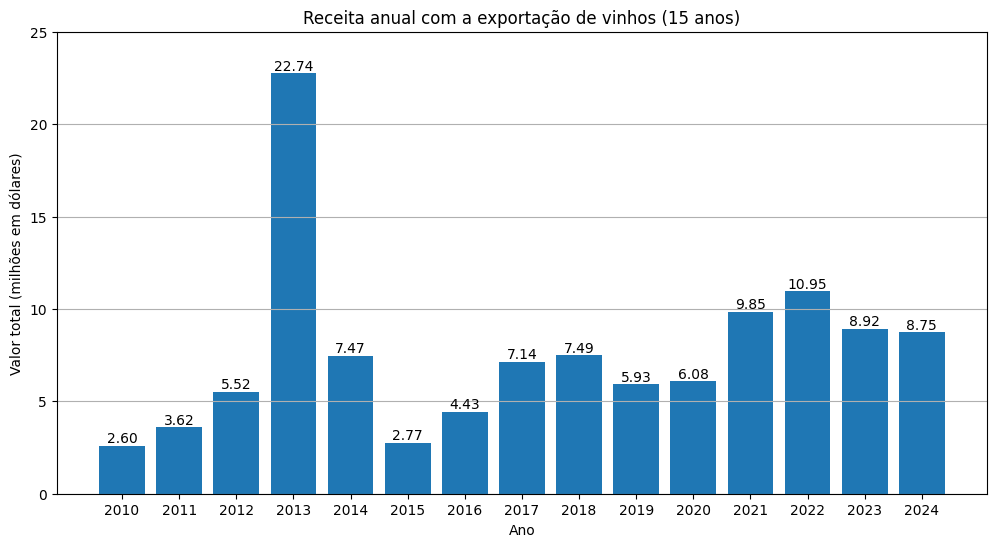

In [28]:
# plota o campo 'Valor' por ano
plota_por_ano('Valor', 'Valor total (milhões em dólares)', 'Receita anual com a exportação de vinhos (15 anos)', 25)

<p>Assim como é perceptível o grande aumento na quantidade de exportação, e na receita no período de 2013, a queda drástica no ano seguinte também é um fator intrigante. E também existem diversos fatores que podem ter influenciado nesse retrato, como:</p>

<ul>
    <li><a href='https://www.estadao.com.br/paladar/bebida/clima-extremo-reduz-safra-2014/?utm_source=chatgpt.com'>Condições climáticas desfavoráveis que resultaram em queda de 20% da produção nacional;</a></li>
    <li><a href='https://economia.uol.com.br/cotacoes/noticias/redacao/2014/12/30/dolar-sobe-13-no-ano-nos-4-anos-de-dilma-salta-60-de-r-167-a-r-266.htm?utm_source=chatgpt.com'>Aumento drástico na valorização do Dólar e incertezas políticas, podem ter gerado desconfiança do mercado internacional frente ao Brasil. </a></li>
</ul>


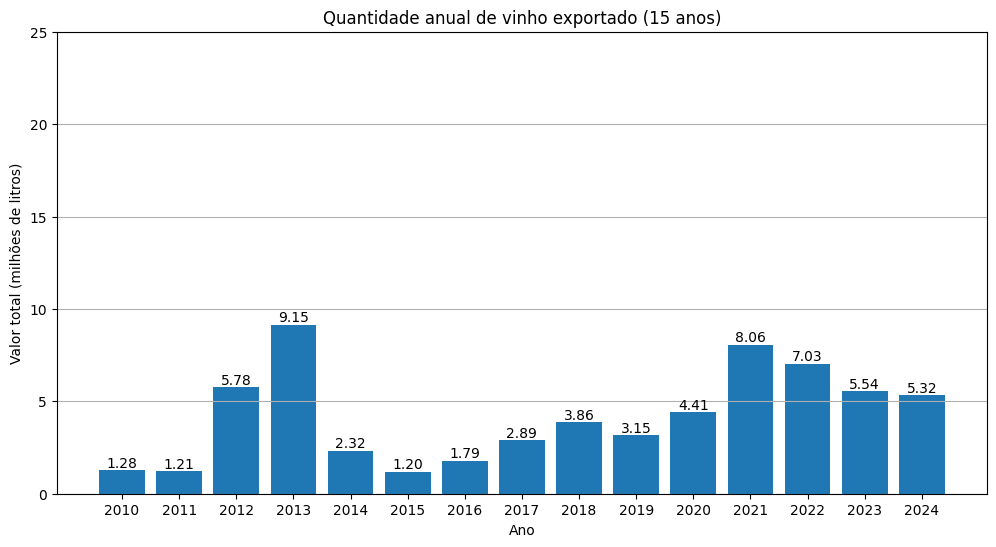

In [29]:
# plota o campo 'Quantidade' por ano
plota_por_ano('Quantidade', 'Valor total (milhões de litros)', 'Quantidade anual de vinho exportado (15 anos)', 25)

<p>Com relação a quantidade de litros de vinhos exportados, é possível analisar que à partir de 2016, houve uma retomada no crescimento da produção e nas exportações, de forma bem moderada. Isso pode ter sido produto de diversos fatores como:</p>
<ul>
    <li><a href='https://istoedinheiro.com.br/vinhos-brasileiros-da-dificil-safra-de-2016-sao-avaliados-por-especialistas/'>Piora na qualidade dos vinhos brasileiros devido a continuação de desfavorecimentos climáticos;</a></li>
    <li><a href='https://istoedinheiro.com.br/producao-mundial-de-vinho-cai-32-em-2016/'>Queda de 3,2% na produção mundial de vinhos;</a></li>
    <li><a href='https://www12.senado.leg.br/noticias/materias/2016/12/28/impeachment-de-dilma-rousseff-marca-ano-de-2016-no-congresso-e-no-brasil'>O impeachment da ex-presidente Dilma Roussef pode também ter sido uma influência, pois o ocorrido gerou grandes impactos socio-econômicos.</a></li>
</ul>

<BarContainer object of 15 artists>

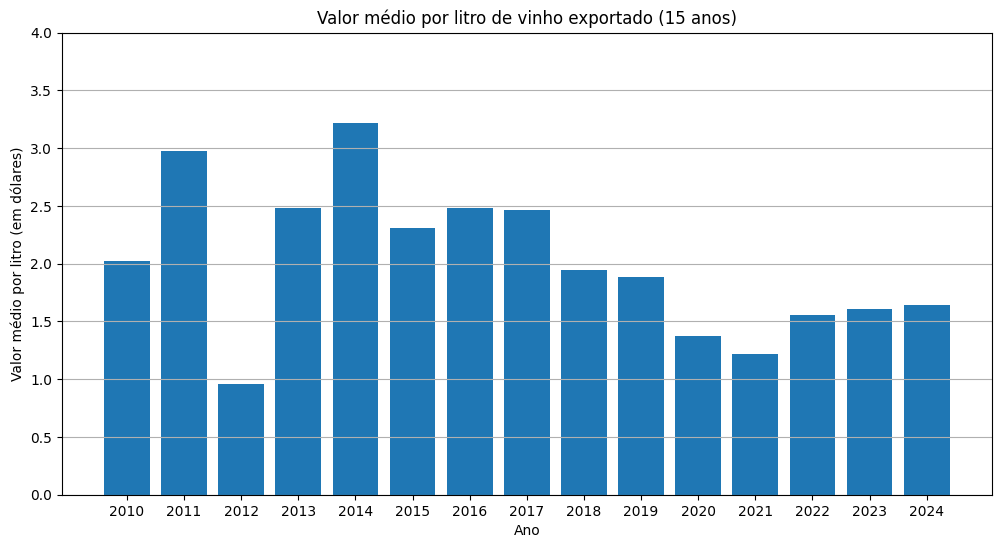

In [30]:
# plota a média anual de litros exportados durante 15 anos
valor_medio_litro = anos_recente.groupby('Ano')['Valor'].sum() / anos_recente.groupby('Ano')['Quantidade'].sum()
fig, ax = plt.subplots(figsize = (12, 6))
ax.set_ylim(0, 4)
ax.set_xticks(valor_medio_litro.index)
ax.grid(axis = 'y')
ax.set_xlabel('Ano')
ax.set_ylabel('Valor médio por litro (em dólares)')
ax.set_title('Valor médio por litro de vinho exportado (15 anos)')
ax.bar(valor_medio_litro.index, valor_medio_litro.values)

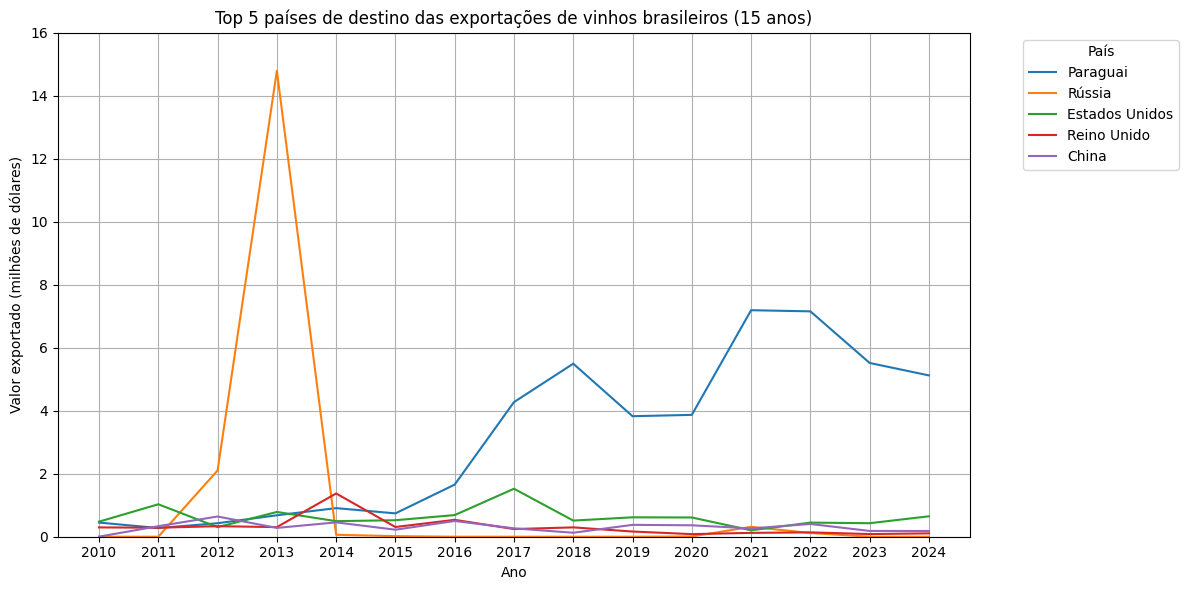

In [31]:
# plota o top 5 países destino de exportação durante 15 anos
top_5_paises = (anos_recente.groupby('País')['Valor'].sum().sort_values(ascending=False).head(5).index)
top_df = anos_recente[anos_recente['País'].isin(top_5_paises)]
df_pivot = top_df.pivot_table(index='Ano', columns='País', values='Valor', aggfunc='sum')
df_pivot = df_pivot / 1_000_000
ordem_colunas = df_pivot.sum().sort_values(ascending=False).index
df_pivot = df_pivot[ordem_colunas]
fig, ax = plt.subplots(figsize=(12, 6))
df_pivot.plot(ax=ax)
ax.set_xticks(df_pivot.index)
ax.set(xlabel='Ano', ylabel='Valor exportado (milhões de dólares)', title='Top 5 países de destino das exportações de vinhos brasileiros (15 anos)')
ax.grid()
ax.set_ylim(0, 16)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='País', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

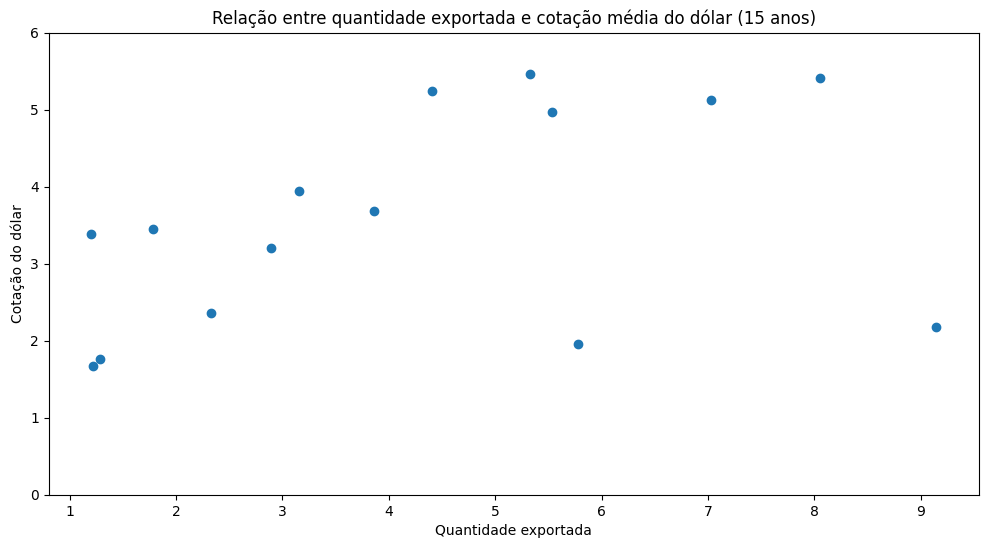

In [34]:
# plota a relação entre quantidade exportada e a cotação do dólar
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(anos_recente.groupby('Ano')['Quantidade'].sum() / 1_000_000, ultima_cotacao_ano.values)
ax.set_ylim(0, 6)
ax.set_xlabel('Quantidade exportada')
ax.set_ylabel('Cotação do dólar')
ax.set_title('Relação entre quantidade exportada e cotação média do dólar (15 anos)')
plt.show()

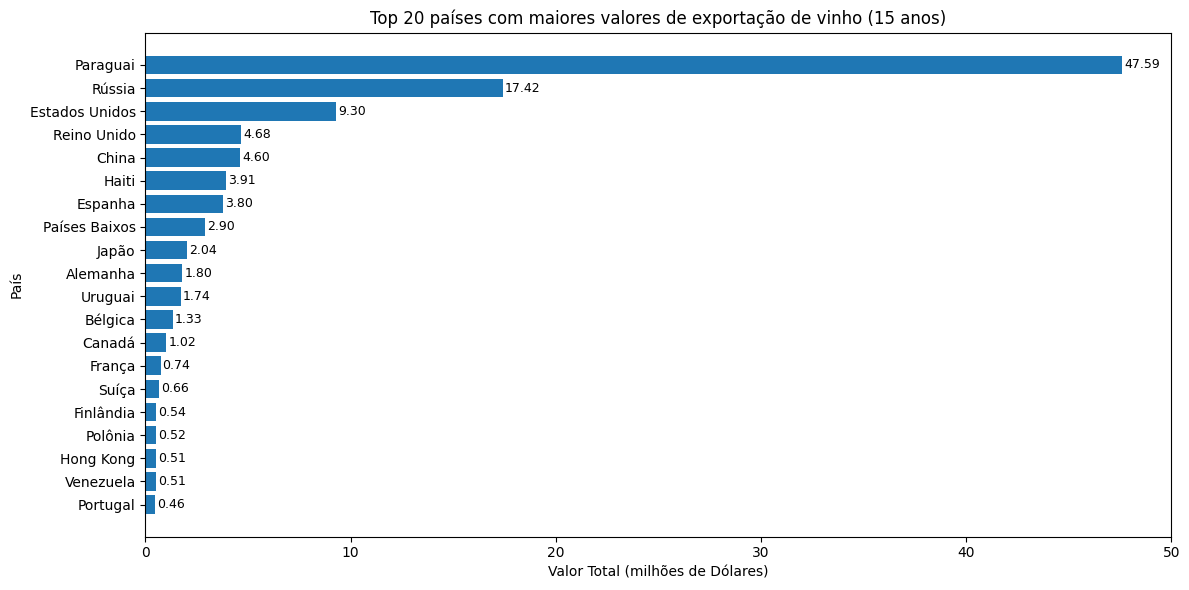

In [35]:
# plota um ranking top 20 países que mais importaram o vinho brasileiro
valores_por_pais = (anos_recente.groupby('País')['Valor'].sum() / 1_000_000)
valores_por_pais = valores_por_pais[valores_por_pais > 0].sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(valores_por_pais.index[::-1], valores_por_pais.values[::-1])

for i, (valor, pais) in enumerate(zip(valores_por_pais.values[::-1], valores_por_pais.index[::-1])):
    ax.text(valor + 0.1, i, f'{valor:.2f}', va='center', fontsize=9)

ax.set_xlim(0, 50)
ax.set_xlabel('Valor Total (milhões de Dólares)')
ax.set_ylabel('País')
ax.set_title('Top 20 países com maiores valores de exportação de vinho (15 anos)')
plt.tight_layout()
plt.show()

## Conclusão

<p>O desempenho das exportações de vinhos brasileiros entre 2013 e os anos seguintes revela como o setor é altamente sensível a fatores externos e internos. O pico em 2013 pode ser atribuído à combinação de uma safra de alta qualidade e à desvalorização do real frente ao dólar, que tornou o produto brasileiro mais competitivo no mercado internacional

A partir de 2014, no entanto, a instabilidade começou a impactar o setor: uma safra prejudicada por condições climáticas extremas reduziu a produção em cerca de 20%, enquanto o agravamento do cenário político e econômico elevou a incerteza no comércio exterior.

Em 2016, o impacto do impeachment da presidente Dilma Rousseff adicionou uma camada de instabilidade política e econômica ao país. Esse processo gerou turbulências nos mercados e pode ter influenciado negativamente a percepção internacional sobre o Brasil. Nesse mesmo ano, houve um aumento bem moderado na quantidade exportada, possivelmente devido a uma piora na qualidade do vinho — reflexo das condições climáticas desfavoráveis e da queda global na produção de vinho.

O cenário pós-2016 revela um setor tentando se recuperar, mas que ainda sofre com as consequências desses fatores.
Os resuldos dos últimos anos demonstram que o setor vitivinícola brasileiro passou a produzir mais, e obter um menor retorno com base na quantidade de litros exportados. Isso evidencia a necessidade de estratégias que agreguem mais valor ao produto nacional, como a qualificação técnica das vinícolas, fortalecimento da imagem do vinho brasileiro no exterior e maior estabilidade econômica e política.</p>